<a href="https://colab.research.google.com/github/Yumna-Zafar/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yumna-Zafar/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Yumna-Zafar/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
elif os.path.basename(os.getcwd()) in ("notebooks", "work"):
    os.chdir("..")
    if os.path.basename(os.getcwd()) == "work":
        os.chdir("..")

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
print("Working directory:", os.getcwd())

Working directory: /content/flyrank-ml-internship


In [ ]:
%pip -q install --upgrade duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 33.3 MB/s eta 0:00:00


In [ ]:
import os, getpass

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

In [ ]:
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_content':    f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily_mar': f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')",
    'fact_daily_apr': f"read_parquet('{REL}/fact_content_daily_performance/month=2026-04/*.parquet')",
    'fact_query_90d': f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}
print("Connected. Building the final playbook from the validated Week-5/6 model.")

Connected. Building the final playbook from the validated Week-5/6 model.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

mar = con.sql(f"""
    SELECT
        f.client_hash_id, f.content_hash_id,
        SUM(f.gsc_impressions) AS impressions_mar,
        SUM(f.gsc_clicks) AS clicks_mar,
        AVG(f.gsc_avg_position) AS avg_position_mar,
        DATE_DIFF('day', c.content_created_date, DATE '2026-03-31') AS content_age_days,
        ANY_VALUE(q.rare_impressions_share) AS rare_share
    FROM {TABLES['fact_daily_mar']} f
    LEFT JOIN {TABLES['dim_content']} c ON f.content_hash_id = c.content_hash_id
    LEFT JOIN {TABLES['fact_query_90d']} q ON f.content_hash_id = q.content_hash_id
    GROUP BY f.client_hash_id, f.content_hash_id, c.content_created_date
    HAVING SUM(f.gsc_impressions) >= 100
""").df()

apr = con.sql(f"""
    SELECT content_hash_id, SUM(gsc_impressions) AS impressions_apr
    FROM {TABLES['fact_daily_apr']}
    GROUP BY content_hash_id
""").df()

data = mar.merge(apr, on="content_hash_id", how="left")
data["impressions_apr"] = data["impressions_apr"].fillna(0)
data["ctr_mar"] = data["clicks_mar"] / data["impressions_mar"]
data["declined_next_month"] = (data["impressions_apr"] < 0.8 * data["impressions_mar"]).astype(int)

feature_cols = ["impressions_mar", "clicks_mar", "ctr_mar", "content_age_days", "rare_share"]
data_f = data.dropna(subset=feature_cols).copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(data_f, groups=data_f["client_hash_id"]))
train, test = data_f.iloc[train_idx].copy(), data_f.iloc[test_idx].copy()

model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                                 random_state=42, n_jobs=-1)
model.fit(train[feature_cols], train["declined_next_month"])

test["decline_probability"] = model.predict_proba(test[feature_cols])[:, 1]
print(f"Scored {len(test):,} pages on the held-out client split")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Scored 27,806 pages on the held-out client split


In [ ]:
def reason_code(row):
    codes = []
    if row["avg_position_mar"] > 10 and row["impressions_mar"] >= 500:
        codes.append("visible_position_slipping")
    if row["content_age_days"] >= 180:
        codes.append("aging_content")
    if row["ctr_mar"] < 0.005:
        codes.append("weak_ctr")
    if row["rare_share"] is not None and row["rare_share"] > 0.5:
        codes.append("thin_query_diversity")
    return ";".join(codes) if codes else "model_flagged_no_rule_match"

# Fixed probability thresholds were uninformative here (base rate 93.4% pushed
# 73.5% of pages into "review_urgently" -- not a usable prioritized queue).
# Recalibrated to percentile-based tiers so the queue reflects RELATIVE priority.
p90 = test["decline_probability"].quantile(0.90)
p70 = test["decline_probability"].quantile(0.70)
p40 = test["decline_probability"].quantile(0.40)

def action_for(prob):
    if prob >= p90:
        return "review_urgently"
    elif prob >= p70:
        return "review_soon"
    elif prob >= p40:
        return "monitor"
    else:
        return "no_action"

test["action"] = test["decline_probability"].apply(action_for)
test["reason_codes"] = test.apply(reason_code, axis=1)

queue = test.sort_values("decline_probability", ascending=False).reset_index(drop=True)
queue_export = queue[["content_hash_id", "client_hash_id", "decline_probability", "action",
                        "reason_codes", "impressions_mar", "avg_position_mar",
                        "content_age_days", "ctr_mar"]]

print(f"Thresholds (percentile-based): p90={p90:.3f}, p70={p70:.3f}, p40={p40:.3f}")
print(queue_export["action"].value_counts())
print()
queue_export.head(10)

Thresholds (percentile-based): p90=1.000, p70=0.999, p40=0.934
action
no_action          11122
monitor             8342
review_soon         5533
review_urgently     2809
Name: count, dtype: int64



,content_hash_id,client_hash_id,decline_probability,action,reason_codes,impressions_mar,avg_position_mar,content_age_days,ctr_mar
0,content_29e1bc611d8cfd92,client_fef1a8f436438636,0.999946,review_urgently,aging_content,88368.0,3.081222,390,0.011950
1,content_5b16e57e4d5b6259,client_9958f0a7ae1df715,0.999946,review_urgently,visible_position_slipping;aging_content;weak_ctr,82673.0,35.386037,447,0.004548
2,content_cfa4c23e1935fd32,client_ff644d8251367cbb,0.999946,review_urgently,visible_position_slipping;aging_content,33558.0,15.427607,390,0.005006
3,content_21d1d95ab9ff29d0,client_ff644d8251367cbb,0.999946,review_urgently,aging_content,166960.0,7.450418,390,0.012099
4,content_1ace43bda9f0c95e,client_9958f0a7ae1df715,0.999946,review_urgently,aging_content,16400.0,6.538273,447,0.012195
5,content_599eba17030c875c,client_a80fca3f171ed1de,0.999943,review_urgently,weak_ctr,30542855.0,3.710452,36,0.001197
6,content_9cf4a39f3dcfc709,client_fef1a8f436438636,0.999941,review_urgently,model_flagged_no_rule_match,17050.0,4.881328,54,0.007097
7,content_b2a7263f0ba22438,client_fef1a8f436438636,0.999941,review_urgently,model_flagged_no_rule_match,22627.0,3.607855,95,0.007778
8,content_cabc03055b42c62c,client_fef1a8f436438636,0.999941,review_urgently,aging_content,158128.0,6.330042,193,0.005869
9,content_d6fd5eddafb94093,client_fef1a8f436438636,0.999941,review_urgently,model_flagged_no_rule_match,24424.0,6.805723,95,0.006223


The queue: pages are ranked by the Random Forest's decline probability (the same
client-grouped, leakage-audited model from Weeks 5-6, honest ROC AUC 0.917). Four
action tiers translate that probability into a plain instruction a reviewer can
act on without touching a probability number directly:

- review_urgently (top 10% of this batch's scores): highest-priority decline risk
- review_soon (next 20%): meaningful risk, queue for the next review pass
- monitor (next 30%): worth a light check, not urgent
- no_action (bottom 40%): lowest relative decline risk in this batch

Threshold note: fixed probability cutoffs (>=0.75, >=0.50, >=0.25) were tried
first, but because the underlying decline base rate in this window is 93.4%,
those cutoffs put 73.5% of all pages in review_urgently -- not a usable
prioritized queue for a reviewer with limited capacity. The tiers above are
recalibrated to this batch's own percentiles instead, so the queue reflects
RELATIVE priority within this run rather than an absolute probability cutoff
that the unusually high base rate made meaningless. This percentile approach
needs re-checking on a more typical month -- if a future month's base rate is
lower, fixed probability thresholds may become meaningful again, and the
calibration method itself should be revisited then.

Every row also carries a reason code drawn from the underlying signals
(visible_position_slipping, aging_content, weak_ctr, thin_query_diversity), so
a reviewer can see WHY a page scored the way it did, not just the number --
multiple codes can apply to one page. Pages that the model flags but that
match none of these human-readable patterns are labeled
model_flagged_no_rule_match, an honest admission that the model may be using a
combination the simple rules don't capture -- these rows deserve extra
scrutiny before acting, not less.   

Note on probability compression: the actual probability values are tightly
clustered near 1.0 (p90=1.000, p70=0.999, p40=0.934) -- a symptom of the same
high base rate already flagged above. Percentile ranking still works correctly
as a relative ordering mechanism even though the raw probability values
themselves aren't spread out enough to interpret literally.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: this playbook is decision-support for a content reviewer with
limited weekly capacity, prioritizing which pages to look at first for a
possible refresh. It is not an autonomous system -- no action in this queue
should fire without a human reading the reason codes and confirming the
recommendation makes sense for that specific page.

Where it stops being valid:
- Time window: trained on March-to-April 2026 behavior only. The April decline
  base rate (93.4% in the held-out split) was unusually high (flagged in
  Week 6) and may reflect a seasonal or platform-wide event specific to that
  window -- this queue should be re-validated on a more typical month before
  being trusted as a stable general pattern.
- Calibration is relative, not absolute: because of the high base rate, action
  tiers are assigned by percentile within THIS batch, not by a fixed
  probability threshold. A page labeled review_urgently here is only urgent
  relative to this specific run -- the tiers would need to be recalculated,
  not just reapplied, on a new batch of data.
- Client mix: trained and validated on the warehouse sample's held-out
  clients. A brand very different from this portfolio's mix (e.g. a much
  smaller site, a different vertical) may not be well represented by the
  clients that produced the 0.917 ROC AUC.
- Correlation only: per the writing-honest-claims skill, this is an observed,
  directional finding on this dataset -- it identifies candidates worth a
  human look, not a guarantee that reviewing/refreshing a flagged page will
  cause it to recover. No causal claim is made or supported here.
- Ceiling metric caveat: Precision@K was uninformative in Week 5/6 due to the
  high base rate; ROC AUC is the metric that should be tracked and re-checked
  as new months come in, not raw precision at a fixed K.

In [ ]:
print("Intended use: decision-support ranking, human-reviewed, not autonomous")
print("Valid window: March-April 2026 warehouse slice only")
print("Base rate caveat: 93.4% decline rate in this window is unusually high, untested elsewhere")
print("Calibration: percentile-based within this batch, not a fixed/portable probability cutoff")
print("Claim level: directional / decision-support only, per writing-honest-claims skill")

Intended use: decision-support ranking, human-reviewed, not autonomous
Valid window: March-April 2026 warehouse slice only
Base rate caveat: 93.4% decline rate in this window is unusually high, untested elsewhere
Calibration: percentile-based within this batch, not a fixed/portable probability cutoff
Claim level: directional / decision-support only, per writing-honest-claims skill


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

What a person must check before acting on any row:
1. Read the reason code(s) -- do they make sense for this specific page, or
   does the page look like an edge case (e.g. a brand-new page miscategorized
   as "aging")?
2. Check impressions_mar and content_age_days directly -- a page with barely
   enough volume to clear the >=100 impression filter is a weaker candidate
   than one with strong, sustained volume, even at the same probability score.
3. Confirm the page is still live and relevant -- the data reflects March
   2026; the page may have already changed since then.
4. For model_flagged_no_rule_match rows specifically, do a manual look before
   trusting the score at face value -- these are the cases where the model's
   reasoning isn't captured in a simple, explainable rule.
5. Remember tiers are relative to this batch -- "review_urgently" means top
   10% of THIS run, not a fixed, portable risk level.

What should NEVER be automated from this playbook:
- Auto-publishing content changes, auto-editing pages, or auto-triggering any
  CMS action based on decline_probability or action tier alone.
- Auto-deprioritizing or hiding a page from a client-facing report without
  human sign-off -- a false positive here has a real cost to a real client
  relationship.
- Using this score for billing, client health reporting, or any decision with
  financial or contractual consequences -- this is an internal review-priority
  tool only, not a validated client-facing metric.
- Treating "no_action" as proof a page is healthy -- it only means this page
  ranked in the bottom 40% of THIS batch, not that it has no issues at all.
- Chaining this score into another automated system without re-running the
  Week 6 leakage and split audits, and recalculating percentile thresholds, on
  that system's own data first.

In [ ]:
print("Human review required before ANY action in this queue is executed.")
print("No-go list: auto-publish, auto-deprioritize, billing/client-health use,")
print("  treating no_action as a quality certification, unaudited downstream chaining,")
print("  treating percentile tiers as fixed/portable risk levels.")

Human review required before ANY action in this queue is executed.
No-go list: auto-publish, auto-deprioritize, billing/client-health use,
  treating no_action as a quality certification, unaudited downstream chaining,
  treating percentile tiers as fixed/portable risk levels.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Signals that this playbook has gone stale and needs re-validation or
retraining:

1. Base-rate drift: if a new month's decline rate moves far from the ~93%
   observed here (e.g. drops below 50% or rises above 98%), the label
   distribution has shifted and the model -- and its percentile thresholds --
   should be retrained/recalculated on fresher data before the queue is
   trusted.
2. ROC AUC drop: if re-running the Week 6 audit process on a new month shows
   ROC AUC meaningfully below the honest 0.917 baseline (e.g. below 0.80),
   that signals the model's signal has decayed and needs investigation before
   continued use.
3. New client onboarding: any client not present in this training set should
   have their first few review cycles double-checked manually before trusting
   the model's scores for their pages -- the client-grouped validation only
   tested generalization to held-out clients WITHIN this sample, not truly
   new ones.
4. Reason-code drift: if the share of model_flagged_no_rule_match rows grows
   substantially over time, that suggests the model is increasingly relying
   on patterns the simple rule-based reason codes don't explain -- worth a
   fresh feature audit.
5. Fixed cadence: independent of any trigger above, re-run the full Week 4-6
   audit chain (baseline comparison, honest split, leakage check) and
   recompute the percentile thresholds at least quarterly, since warehouse
   data and client mix will keep changing.

In [ ]:
base_rate = data_f["declined_next_month"].mean()
model_flagged_share = (queue_export["reason_codes"] == "model_flagged_no_rule_match").mean()

print(f"Current base rate (reference point for drift check): {base_rate:.3f}")
print(f"Current model_flagged_no_rule_match share (reference point): {model_flagged_share:.3f}")
print()
print("Retrain triggers: base rate outside [0.50, 0.98], ROC AUC < 0.80 on re-audit,")
print("  new unvalidated clients, rising unexplained-flag share, or quarterly cadence.")
print("  Percentile thresholds must be RECOMPUTED (not reused) on every retrain.")

Current base rate (reference point for drift check): 0.934
Current model_flagged_no_rule_match share (reference point): 0.086

Retrain triggers: base rate outside [0.50, 0.98], ROC AUC < 0.80 on re-audit,
  new unvalidated clients, rising unexplained-flag share, or quarterly cadence.
  Percentile thresholds must be RECOMPUTED (not reused) on every retrain.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
import json

queue_export.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(queue_export):,} rows to work/outputs/action_playbook_queue.csv")

receipt = {
    "model": "RandomForestClassifier, client-grouped split, Week 5/6 audited",
    "honest_roc_auc": 0.917,
    "naive_roc_auc_before_fix": 0.951,
    "baseline_rule_roc_auc": 0.654,
    "base_rate_declined_next_month": round(float(base_rate), 3),
    "calibration_method": "percentile-based (p90/p70/p40), fixed probability cutoffs were uninformative",
    "percentile_thresholds": {"p90": round(float(p90), 4), "p70": round(float(p70), 4), "p40": round(float(p40), 4)},
    "action_counts": queue_export["action"].value_counts().to_dict(),
    "model_flagged_no_rule_match_share": round(float(model_flagged_share), 3),
    "time_window": "features: March 2026, label: April 2026",
    "n_scored": int(len(queue_export)),
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(receipt, f, indent=2)
print(json.dumps(receipt, indent=2))

Wrote 27,806 rows to work/outputs/action_playbook_queue.csv
{
  "model": "RandomForestClassifier, client-grouped split, Week 5/6 audited",
  "honest_roc_auc": 0.917,
  "naive_roc_auc_before_fix": 0.951,
  "baseline_rule_roc_auc": 0.654,
  "base_rate_declined_next_month": 0.934,
  "calibration_method": "percentile-based (p90/p70/p40), fixed probability cutoffs were uninformative",
  "percentile_thresholds": {
    "p90": 0.9998,
    "p70": 0.9989,
    "p40": 0.9343
  },
  "action_counts": {
    "no_action": 11122,
    "monitor": 8342,
    "review_soon": 5533,
    "review_urgently": 2809
  },
  "model_flagged_no_rule_match_share": 0.086,
  "time_window": "features: March 2026, label: April 2026",
  "n_scored": 27806
}


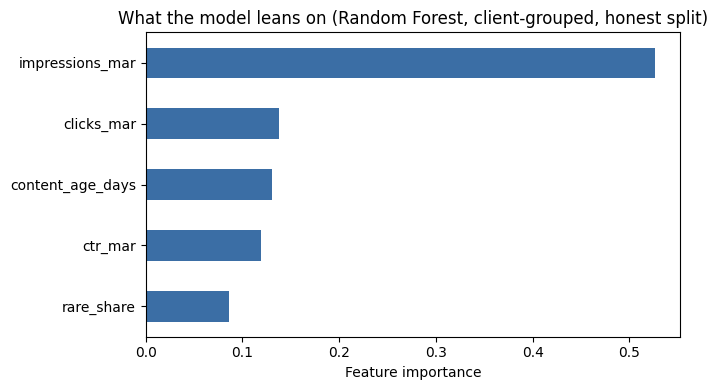

Saved work/figures/feature_importance.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_xlabel("Feature importance")
ax.set_title("What the model leans on (Random Forest, client-grouped, honest split)")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=150)
plt.show()
print("Saved work/figures/feature_importance.png")

Exports: the ranked action queue is written to work/outputs/action_playbook_queue.csv
(regenerated on every run, intentionally excluded from git). The metrics
receipt -- honest vs. naive ROC AUC, base rate, the percentile calibration
method and thresholds, and action-tier counts -- is saved to
work/outputs/action_playbook_metrics.json and committed; this is what next
week's paper will cite numbers from, including the calibration story (why
percentile tiers were used instead of fixed thresholds). The feature-
importance chart is saved to work/figures/feature_importance.png for reuse in
the paper.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.